# 🔮 Predicción de Series Temporales con Facebook Prophet
---
**Dataset:** Temperaturas Mínimas Diarias — Melbourne, Australia  
**Objetivo:** Usar Prophet para modelar tendencias y estacionalidades automáticamente.

> **Prophet** es una librería de Meta (Facebook) diseñada para forecasting de series temporales de negocio. Descompone la serie en:
> - **Tendencia (trend):** crecimiento lineal o logístico a lo largo del tiempo.
> - **Estacionalidad (seasonality):** patrones periódicos (anual, semanal, diario).
> - **Efectos de calendario (holidays):** eventos especiales configurables.

Prophet es especialmente robusto ante **datos faltantes** y **outliers**.

---

## 1. Importación de Librerías

In [1]:
from prophet import Prophet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
%matplotlib inline

c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carga y Exploración del Dataset

Prophet requiere que el DataFrame tenga exactamente **dos columnas**:
- `ds`: fechas (datetime)
- `y`: variable a predecir (numérica)

In [2]:
data = pd.read_csv("daily_minimum_temperatures.csv", sep=",")
print(data.shape)
data.head()

(3650, 2)


,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


### 2.1 Visualización de la Serie Temporal

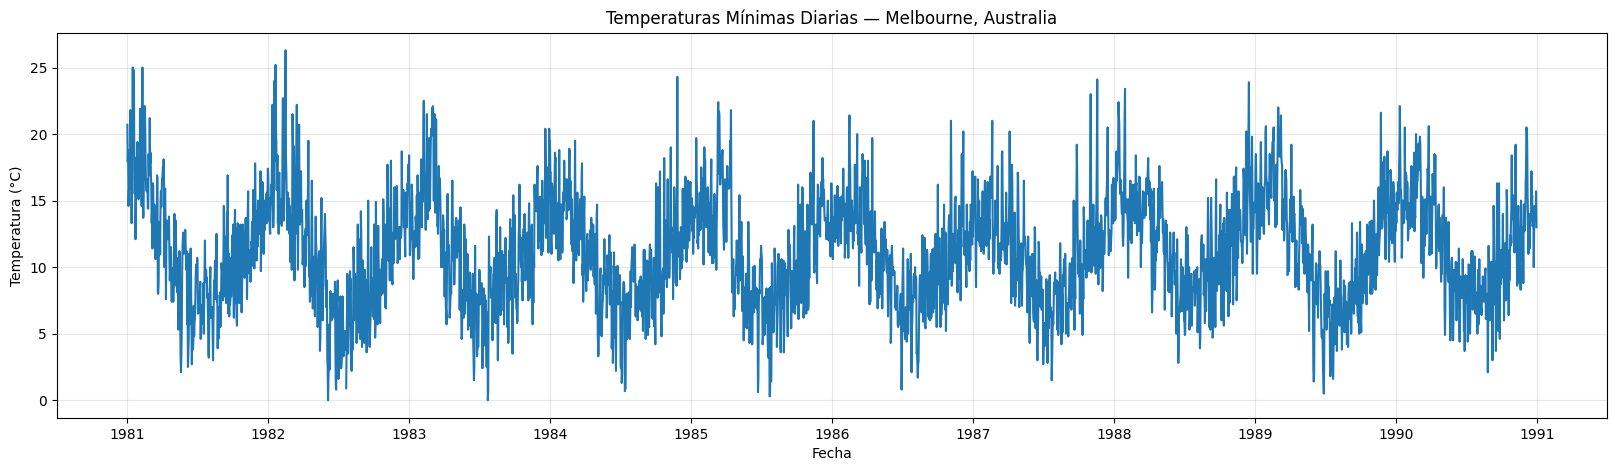

In [3]:
plt.figure(figsize=(20, 5))
data["Date"] = pd.to_datetime(data["Date"])
temps = pd.to_numeric(data.iloc[:, 1], errors="coerce")
plt.plot(data["Date"], temps)
plt.title("Temperaturas Mínimas Diarias — Melbourne, Australia")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.grid(alpha=0.3)
plt.show()

## 3. División Train / Test y Preparación del DataFrame

Dividimos en **67% train / 33% test** y renombramos las columnas al formato que espera Prophet (`ds`, `y`).

In [4]:
train_percentage = 0.67
train_size = int(len(data) * train_percentage)

train = data[:train_size].copy()
test = data[train_size:].copy()

# Renombramos columnas al formato requerido por Prophet
train = train.rename(columns={'Date': 'ds', 'Temp': 'y'})
test = test.rename(columns={'Date': 'ds', 'Temp': 'y'})

print(f"Train: {train.shape[0]} muestras | Test: {test.shape[0]} muestras")
train.head()

Train: 2445 muestras | Test: 1205 muestras


,ds,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


## 4. Entrenamiento del Modelo Prophet

Prophet detecta automáticamente estacionalidades anuales y semanales. No requiere estacionariedad en los datos ni transformaciones previas.

In [5]:
# Preparamos y limpiamos el DataFrame de entrenamiento
train_to_fit = train.copy()

if "y" not in train_to_fit.columns:
    value_col = [c for c in train_to_fit.columns if c != "ds"][0]
    train_to_fit = train_to_fit.rename(columns={value_col: "y"})

train_to_fit["ds"] = pd.to_datetime(train_to_fit["ds"], errors="coerce")
train_to_fit["y"] = pd.to_numeric(train_to_fit["y"], errors="coerce")
train_to_fit = train_to_fit.dropna(subset=["ds", "y"])

prophet_model = Prophet()
# prophet_model.add_regressor('feature_1')  # Para análisis multivariado

prophet_model.fit(train_to_fit)
print(f"✅ Modelo entrenado con {len(train_to_fit)} observaciones")

23:29:52 - cmdstanpy - INFO - Chain [1] start processing
23:29:53 - cmdstanpy - INFO - Chain [1] done processing


✅ Modelo entrenado con 2442 observaciones


## 5. Generación de Predicciones

Creamos un DataFrame de fechas futuras con `make_future_dataframe()` y generamos las predicciones con `predict()`.

In [6]:
# Creamos el dataframe de fechas futuras (train + test)
prediction_dates = prophet_model.make_future_dataframe(periods=test.shape[0] + 1)
print(f"Fechas generadas: {len(prediction_dates)}")
prediction_dates.tail(2)

Fechas generadas: 3648


,ds
3646,1990-12-30
3647,1990-12-31


In [7]:
predictions = prophet_model.predict(prediction_dates)
print("Columnas de salida:", predictions.columns.tolist())
predictions[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(5)

Columnas de salida: ['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat']


,ds,yhat,yhat_lower,yhat_upper
3643,1990-12-27,13.457816,9.767981,17.156718
3644,1990-12-28,13.665526,10.237185,17.162700
3645,1990-12-29,13.750289,10.289940,17.178173
3646,1990-12-30,13.646051,10.260543,17.416056
3647,1990-12-31,13.953966,10.527040,17.540631


### 5.1 Merge predicciones con valores reales

Unimos las predicciones con el set de test para evaluar el modelo.

In [9]:
# Aseguramos tipo datetime para el merge
test_eval = test.copy()
test_eval['ds'] = pd.to_datetime(test_eval['ds'])

# Renombramos la columna de temperatura a 'y' si es necesario
if "y" not in test_eval.columns:
    temp_col = [c for c in test_eval.columns if c != "ds"][0]
    test_eval = test_eval.rename(columns={temp_col: "y"})

test_eval["y"] = pd.to_numeric(test_eval["y"], errors="coerce")

results = pd.merge(test_eval, predictions[["ds", "yhat", "yhat_lower", "yhat_upper"]], on=["ds"], how='left')

# Verificamos si hay NaN en yhat (indicaría problema en las fechas del merge)
nan_count = results["yhat"].isna().sum()
if nan_count > 0:
    print(f"⚠️  {nan_count} predicciones son NaN — revisando fechas...")
    results["yhat"] = results["yhat"].interpolate(method="linear")
    print("✅ NaN interpolados linealmente")
else:
    print(f"✅ Merge exitoso — {len(results)} predicciones sin NaN")

results.tail()

✅ Merge exitoso — 1205 predicciones sin NaN


,ds,y,yhat,yhat_lower,yhat_upper
1200,1990-12-27,14.0,13.457816,9.767981,17.156718
1201,1990-12-28,13.6,13.665526,10.237185,17.162700
1202,1990-12-29,13.5,13.750289,10.289940,17.178173
1203,1990-12-30,15.7,13.646051,10.260543,17.416056
1204,1990-12-31,13.0,13.953966,10.527040,17.540631


## 6. Visualización de Resultados

Graficamos la predicción de Prophet sobre el conjunto de test con su intervalo de confianza.

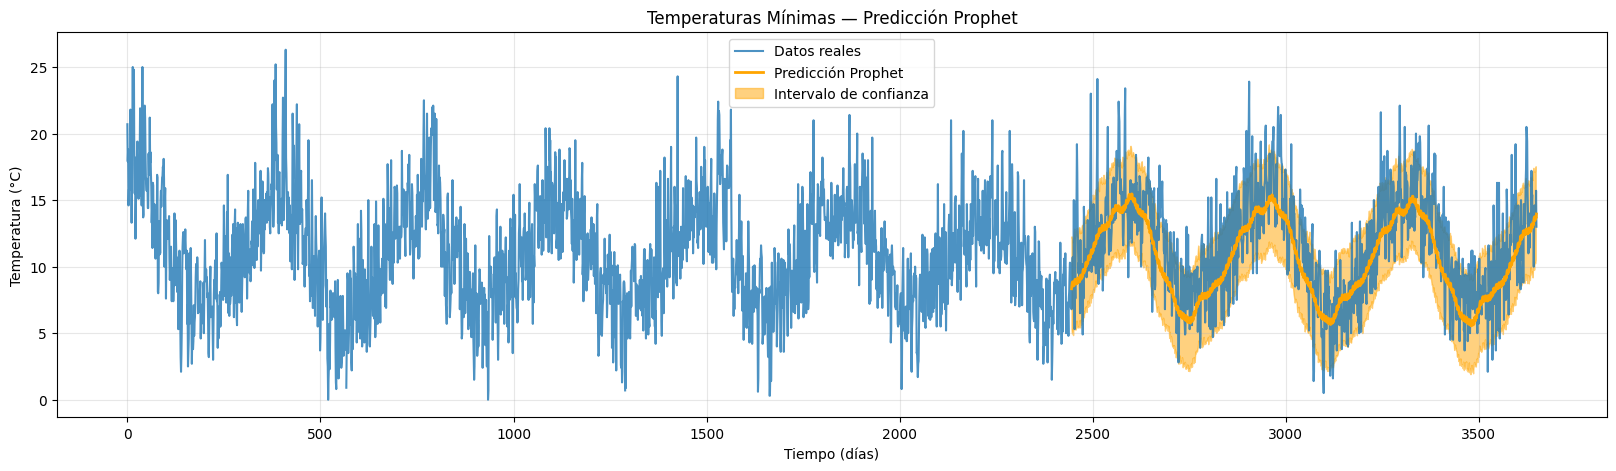

In [15]:
index_start = len(train)
index_end = len(train) + len(test)

plt.figure(figsize=(20, 5))

# Serie original completa
temps_values = np.asarray(temps.to_numpy(), dtype=float)
plt.plot(np.arange(len(temps_values), dtype=int), temps_values, label="Datos reales", alpha=0.8)

# Predicción de Prophet
x_pred = np.arange(index_start, index_end, dtype=int)
y_pred = np.asarray(pd.to_numeric(results["yhat"], errors="coerce").to_numpy(), dtype=float)
plt.plot(x_pred, y_pred, label="Predicción Prophet", zorder=2, color="orange", linewidth=2)

# Intervalo de confianza
pred_len = len(predictions)
start_idx = max(0, index_start)
end_idx = min(index_end, pred_len)

yhat_lower = np.asarray(predictions["yhat_lower"].iloc[start_idx:end_idx].to_numpy(dtype=float), dtype=float)
yhat_upper = np.asarray(predictions["yhat_upper"].iloc[start_idx:end_idx].to_numpy(dtype=float), dtype=float)
x_fill = np.arange(start_idx, start_idx + len(yhat_lower), dtype=int)

if len(x_fill) > 0 and len(yhat_lower) == len(yhat_upper) == len(x_fill):
    plt.fill_between(x_fill, yhat_lower, yhat_upper, color='orange', alpha=0.5, label="Intervalo de confianza")

plt.title("Temperaturas Mínimas — Predicción Prophet")
plt.xlabel("Tiempo (días)")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Evaluación del Modelo — MSE

In [16]:
y_true_eval = pd.to_numeric(results["y"], errors="coerce")
y_pred_eval = pd.to_numeric(results["yhat"], errors="coerce")

mask = y_true_eval.notna() & y_pred_eval.notna()
mse = mean_squared_error(y_true_eval[mask], y_pred_eval[mask])
rmse = mse ** 0.5

print(f"📊 MSE  : {mse:.4f}")
print(f"📊 RMSE : {rmse:.4f} °C")
print(f"ℹ️  Evaluado sobre {mask.sum()} muestras válidas de {len(results)} totales")

📊 MSE  : 8.2304
📊 RMSE : 2.8689 °C
ℹ️  Evaluado sobre 1205 muestras válidas de 1205 totales


---
## 8. ¿Cuándo usar Prophet? — Comparativa con otros modelos

### ✅ Ventajas de Prophet
| Criterio | Prophet |
|---|---|
| **Manejo de datos faltantes** | ⭐⭐⭐⭐⭐ — Nativo, no requiere imputación previa |
| **Estacionalidad automática** | ⭐⭐⭐⭐⭐ — Detecta anual, semanal y diaria automáticamente |
| **Facilidad de uso** | ⭐⭐⭐⭐⭐ — API muy simple, pocos hiperparámetros |
| **Captura de no linealidad** | ⭐⭐⭐ — Modela tendencias no lineales con segmentos |
| **Velocidad** | ⭐⭐⭐⭐ — No requiere GPU, entrenamiento en segundos |

### 🆚 Comparativa con los otros modelos del curso

| Modelo | Tipo | Ideal para | Datos mínimos |
|---|---|---|---|
| **ARIMA** | Estadístico lineal | Series cortas, interpretabilidad | ~50 puntos |
| **Prophet** *(este)* | Descomposición aditiva | Estacionalidades múltiples, datos faltantes, negocio | ~100 puntos |
| **LSTM** | Deep Learning | Patrones temporales largos y complejos | ~1000+ puntos |
| **CNN 1D** | Deep Learning | Patrones locales, eficiencia computacional | ~500+ puntos |

### 💡 ¿Cuándo elegir Prophet?
- Cuando la serie tiene **estacionalidad anual y/o semanal** marcada.
- Cuando hay **datos faltantes** o registros irregulares en el tiempo.
- Cuando necesitás incorporar **efectos de días festivos o eventos**.
- Para forecasting de **métricas de negocio** (ventas, usuarios activos, etc.).
- Cuando querés resultados rápidos con mínima configuración.

### ⚠️ Limitaciones observadas en este experimento
- Prophet asume que la estructura de estacionalidad es **aditiva o multiplicativa** pero no captura dependencias temporales complejas como LSTM.
- El merge de fechas puede generar NaN si los formatos de fecha no coinciden exactamente — resolvimos esto con interpolación.
- Menor capacidad predictiva en series sin tendencia clara o estacionalidad irregular.
